In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY293dmluL0RvY3VtZW50cy9hcHJlbmRpemFkb19tYXF1aW5hX21lc3RyYWRv'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/importlib/_bootstrap.py": 1762086091.1224008, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/importlib/_bootstrap_external.py": 1762086091.122762, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/zipimport.py": 1762086091.3777666, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/codecs.py": 1762086090.9207585, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/encodings/aliases.py": 1762086090.9473386, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/encodings/__init__.py": 1762086090.946759, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/encodings/utf_8.py": 1762086090.9592876, "/home/cowvin/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/abc.py": 1762086090.90975

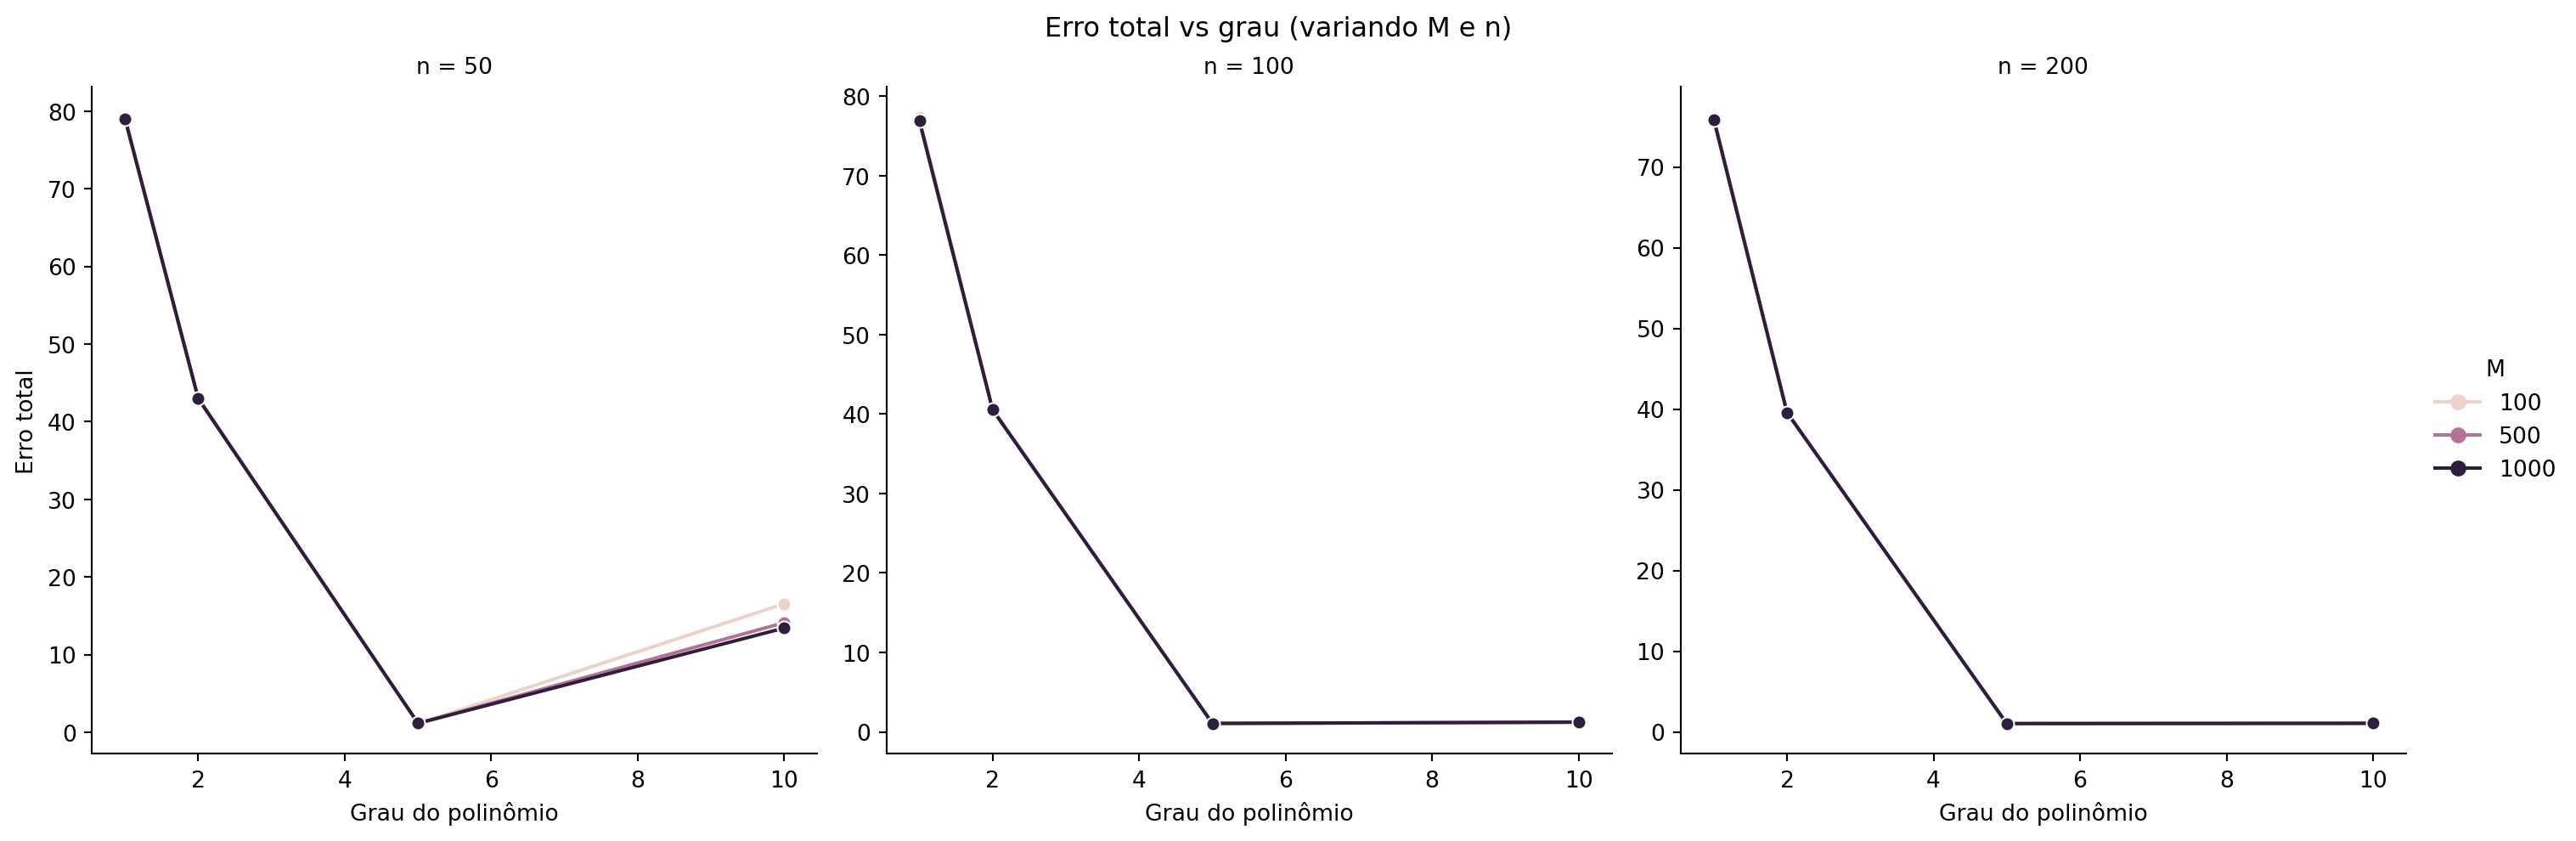

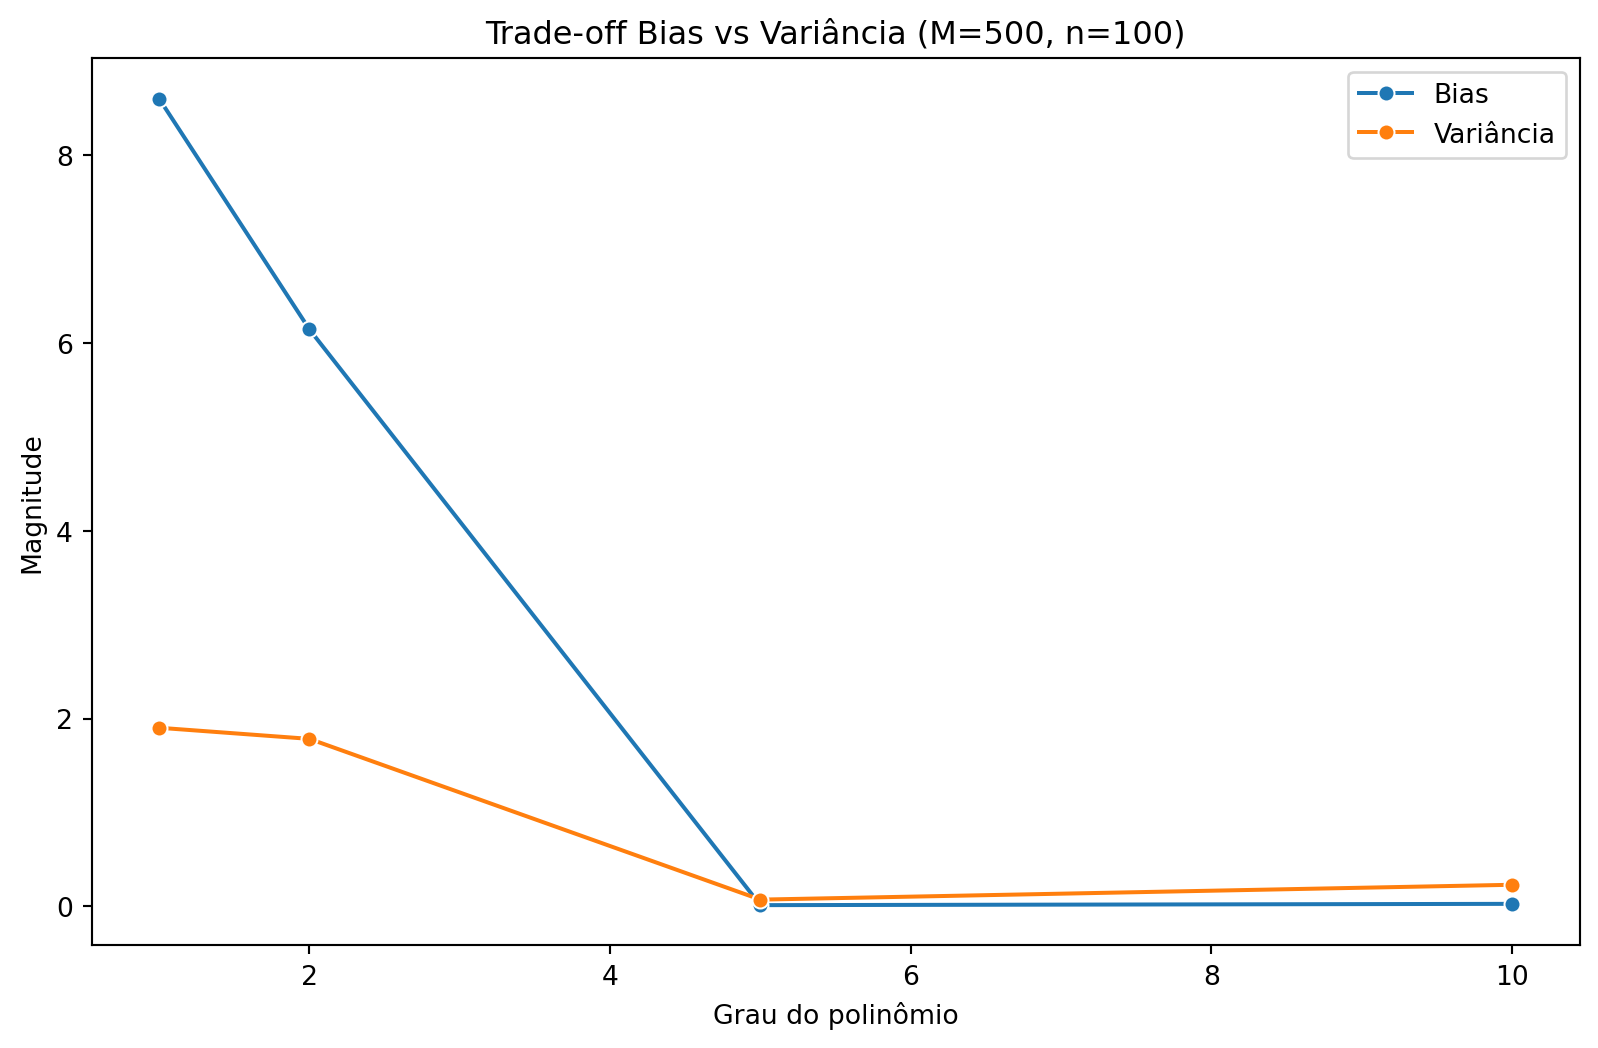

In [2]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from numpy.random import uniform, normal

def simulate_exercise_1(M=500, n=100, grid_n=200, degrees=[1, 2, 5, 10]):

    f_x = lambda x: 5 * x**2 * (1 - x)
    results = []
    X_simulated = []
    y_simulated = []

    N = 0
    sum_irreducible = 0

    np.random.seed(0)
    grid = np.linspace(-2, 2, grid_n)

    for sample in range(M):
        X_train = uniform(-2, 2, n)
        y_train = f_x(X_train) + normal(0, 1, n)

        N += len(X_train)
        sum_irreducible += np.sum((y_train - f_x(X_train)) ** 2)

        for degree in degrees:
            poly = PolynomialFeatures(degree=degree)
            X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
            f_hat = LinearRegression(fit_intercept=False).fit(
                X=X_train_poly, y=y_train
            )
            X_train_poly_grid = poly.transform(grid.reshape(-1, 1))

            preds = f_hat.predict(X_train_poly_grid)

            for i, pred in enumerate(preds):
                results.append(
                    {
                        "sample": sample,
                        "degree": degree,
                        "f_hat": f_hat,
                        "x_grid_id": i,
                        "prediction_grid": pred,
                    }
                )

    fitted_models = pd.DataFrame(results)\
        .assign(
            f_bar_hat=lambda x: x.groupby(
                ["degree", "x_grid_id"]
            )["prediction_grid"].transform("mean"),
            bias2 = lambda x: (x.f_bar_hat - f_x(grid[x.x_grid_id]))**2,
            var_hat=lambda x: x.groupby(
                ["degree", "x_grid_id"]
            ).prediction_grid.transform(lambda y: y.var(ddof=0)),
            sigma2_hat=sum_irreducible / N,
            total_error=lambda x: x.bias2 + x.var_hat + x.sigma2_hat
        ).groupby("degree").agg(
            bias2=("bias2", "mean"),
            var_hat=("var_hat", "mean"),
            sigma2_hat=("sigma2_hat", "mean"),
            total_error=("total_error", "mean")
        ).reset_index()

    return fitted_models

results_first_question = simulate_exercise_1()

Ms = [100, 500, 1000]
ns = [50, 100, 200]

final_summary = pd.concat(
    [
        simulate_exercise_1(M=M, n=n).assign(M=M, n=n)
        for M, n in itertools.product(Ms, ns)
    ],
    ignore_index=True
)

g = sns.relplot(
    data=final_summary,
    x="degree",
    y="total_error",
    hue="M",
    col="n",
    kind="line",
    marker="o",
    facet_kws={"sharex": True, "sharey": False},
)
g.set_axis_labels("Grau do polinômio", "Erro total")
g.fig.suptitle("Erro total vs grau (variando M e n)", y=1.02)
plt.show()

df_plot = (
    final_summary.query("M == 500 & n == 100")
    .assign(bias=lambda x: np.sqrt(x.bias2))
    .sort_values("degree")
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_plot, x="degree", y="bias", marker="o", label="Bias", ax=ax)
sns.lineplot(data=df_plot, x="degree", y="var_hat", marker="o", label="Variância", ax=ax)

ax.set_xlabel("Grau do polinômio")
ax.set_ylabel("Magnitude")
ax.set_title("Trade-off Bias vs Variância (M=500, n=100)")
ax.legend()
plt.show()